# GNN-Guided PCB Autorouting

This notebook builds the full machine learning pipeline for routing a PCB with graph neural networks. It starts from raw board data and ends with a routed, evaluated and plotted net, without needing KiCad.

The idea is simple. A GCN or a GAT predicts which grid cells a good route is likely to pass through, and A* uses those predictions to find the actual path. A* keeps every hard constraint, so a wrong prediction can slow the search down but can never produce an invalid route.

The routed output here is a grid representation of the net, not a `.kicad_pcb` file. Phase 18 explains how to move on to real KiCad boards.

**How to run:** in Colab, choose `Runtime -> Change runtime type -> GPU (T4)`, then `Runtime -> Run all`.

## Phase 1: Environment and Setup

This phase installs PyTorch Geometric and loads the libraries. Its compiled extensions only work with the exact torch and CUDA build that Colab provides, so we read that build from the runtime and install to match it instead of pinning a version.

### Cell 1: Check the PyTorch build

Prints the torch version and whether a GPU is available, and builds the version strings used for the install.

In [ ]:
import torch
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# PyG wheels must match the running torch/CUDA build, so read the versions from the runtime.
TORCH_VERSION = torch.__version__.split('+')[0]
CUDA_VERSION = ('cu' + torch.version.cuda.replace('.', '')) if torch.cuda.is_available() else 'cpu'


Torch version: 2.11.0+cu128
CUDA available: True


### Cell 2: Install PyTorch Geometric

Installs `torch_geometric` and its compiled extensions for the detected torch and CUDA build.

In [ ]:
# Install PyG and its compiled extensions (wheels must match the torch/CUDA build).
!pip install -q torch_geometric
!pip install -q pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv \
    -f https://data.pyg.org/whl/torch-{TORCH_VERSION}+{CUDA_VERSION}.html


  Preparing metadata (setup.py) ... done


### Cell 3: Imports, seeds and output folders

Loads every library used later, fixes the random seeds and creates the `checkpoints` and `results` folders.

In [ ]:
import os, random, time, json, math, heapq
from collections import deque

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, ConfusionMatrixDisplay,
)

# Fix seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", DEVICE)

# Output folders. Colab wipes these on a runtime reset, so download them or mount Drive to keep them.
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)


Using device: cuda


## Phase 2: Dataset and Synthetic Boards

The project names two open datasets, PCBench and PCBWorld. Their file formats need to be inspected by hand in Colab before they can be parsed reliably, so this phase does two things.

First, it gives the clone commands and a parser stub, `load_real_board`, to fill in once the formats are known. Second, it generates synthetic boards in the exact grid format planned for real boards, where every cell is a routing node described by its position, layer, obstacle and net.

Because the format is the same, the whole pipeline can be built and tested now, and real boards can be dropped in later without changing anything downstream.

### Cell 4: Real dataset hook

An optional switch to clone the real datasets, plus a stub for parsing a real board. The stub is left unfilled for now.

In [ ]:
# Set to True to clone the real datasets (needs internet access).
DOWNLOAD_REAL_DATA = False

if DOWNLOAD_REAL_DATA:
    !git clone --depth 1 https://github.com/PCBench/PCBench.git
    !git clone --depth 1 https://github.com/LGAI-Research/PCBWorld.git


def load_real_board(board_path):
    """
    TODO: parse a real board once the PCBench/PCBWorld file formats have been inspected.
    It must return the same dict as generate_synthetic_board() below:
        {'id': int, 'size': int, 'layers': int, 'grid': np.ndarray[layers,size,size],
         'nets': [{'source': (x, y, layer), 'target': (x, y, layer)}, ...]}
    Nothing downstream changes as long as this schema stays the same.
    """
    raise NotImplementedError(
        "Fill in once PCBench/PCBWorld file formats have been inspected in Colab."
    )


### Cell 5: Synthetic board generator

Creates 40 boards of different sizes and congestion levels, each with several nets to route.

In [ ]:
# Synthetic board generator. Each grid cell is a routing node, so the pipeline can run
# before real board data is plugged in.
def generate_synthetic_board(board_id, size=24, n_layers=2, n_nets=6,
                              obstacle_density=0.18, seed=0):
    rng = np.random.RandomState(seed)
    grid = np.zeros((n_layers, size, size), dtype=np.int8)  # 0 = free, 1 = obstacle

    # Scatter random obstacles on layer 0.
    n_obstacles = int(obstacle_density * size * size)
    for _ in range(n_obstacles):
        ox, oy = rng.randint(0, size), rng.randint(0, size)
        grid[0, ox, oy] = 1

    # Pick a source/target pair from the free cells for each net.
    free_cells = [(x, y) for x in range(size) for y in range(size) if grid[0, x, y] == 0]
    rng.shuffle(free_cells)
    nets, used, idx = [], set(), 0
    while len(nets) < n_nets and idx + 1 < len(free_cells):
        s, t = free_cells[idx], free_cells[idx + 1]
        idx += 2
        if s in used or t in used:
            continue
        used.add(s); used.add(t)
        nets.append({'source': (s[0], s[1], 0), 'target': (t[0], t[1], 0)})

    return {'id': board_id, 'size': size, 'layers': n_layers, 'grid': grid, 'nets': nets}


# Boards of varying size and congestion.
BOARD_CONFIGS = (
    [{'size': 16, 'n_nets': 4, 'obstacle_density': 0.10}] * 14 +  # small / light
    [{'size': 24, 'n_nets': 6, 'obstacle_density': 0.18}] * 18 +  # medium
    [{'size': 32, 'n_nets': 8, 'obstacle_density': 0.28}] * 8     # large / congested
)

boards = [generate_synthetic_board(board_id=i, seed=i, **cfg)
          for i, cfg in enumerate(BOARD_CONFIGS)]
print(f"Generated {len(boards)} synthetic boards "
      f"({sum(len(b['nets']) for b in boards)} nets total).")


Generated 40 synthetic boards (228 nets total).


## Phase 3: Ground-Truth Routes

The model needs labels, and we do not have human-routed boards yet. So a classical BFS finds the shortest path for every net, and the GNN learns to imitate it. This is a standard imitation learning setup where a search algorithm plays the expert.

Nets that BFS cannot route are dropped, so every training example has a valid target.

### Cell 6: BFS labels

Runs BFS on every net and stores the path as the label. Boards left with no routable nets are removed.

In [ ]:
def bfs_shortest_path(grid, source, target):
    """
    BFS on the routing grid (single layer, 4-directional moves).
    Returns the shortest path as a list of (x, y) cells, or None if the net
    cannot be routed. Used as the ground-truth label.
    """
    layer = 0  # synthetic boards only use layer 0
    size = grid.shape[1]
    sx, sy, _ = source
    tx, ty, _ = target

    visited = np.zeros((size, size), dtype=bool)
    prev = {}
    q = deque([(sx, sy)])
    visited[sx, sy] = True

    while q:
        x, y = q.popleft()
        if (x, y) == (tx, ty):
            break
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx_, ny_ = x + dx, y + dy
            if 0 <= nx_ < size and 0 <= ny_ < size and not visited[nx_, ny_] \
               and grid[layer, nx_, ny_] == 0:
                visited[nx_, ny_] = True
                prev[(nx_, ny_)] = (x, y)
                q.append((nx_, ny_))

    if not visited[tx, ty]:
        return None

    # Walk back from the target to rebuild the path.
    path = [(tx, ty)]
    while path[-1] != (sx, sy):
        path.append(prev[path[-1]])
    path.reverse()
    return path


def preprocess_board(board):
    """Attach a BFS ground-truth path to every net; drop nets BFS could not route."""
    routable_nets = []
    for net in board['nets']:
        path = bfs_shortest_path(board['grid'], net['source'], net['target'])
        if path is not None:
            net = dict(net)
            net['gt_path'] = path
            routable_nets.append(net)
    board = dict(board)
    board['nets'] = routable_nets
    return board


boards = [preprocess_board(b) for b in boards]
boards = [b for b in boards if len(b['nets']) > 0]  # drop boards with zero routable nets
print(f"{len(boards)} boards retained after preprocessing "
      f"({sum(len(b['nets']) for b in boards)} routable nets).")


40 boards retained after preprocessing (226 routable nets).


## Phase 4: PCB to Graph

This is where a board becomes the graph the GNNs learn on. Each grid cell is a node connected to its four neighbours. One graph is built for every (board, net) pair, with that net's source and target flagged.

- **Node features (7):** `x_norm`, `y_norm`, `layer`, `obstacle`, `is_source`, `is_target`, `local_occupancy`
- **Edge features (5):** `dx`, `dy`, `distance`, `legality`, `layer_transition` (the last one is reserved for vias later)
- **Label:** 1 if the cell is on the BFS path for that net, otherwise 0

Details that differ in shape from board to board (the obstacle grid, the source and the target) are kept in a separate `GRAPH_META` list instead of on the `Data` object. This lets the `DataLoader` batch graphs from boards of different sizes.

### Cell 7: Build the graphs

Converts each (board, net) pair into a PyG graph and stores the board details in `GRAPH_META`.

In [ ]:
GRAPH_META = []  # GRAPH_META[data.uid] -> {'board_id','size','source','target','grid'}

def meta_of(data):
    """Look up the non-tensor routing metadata (grid, source, target, ...) for a graph."""
    return GRAPH_META[data.uid]


def board_net_to_graph(board, net):
    """
    Convert one (board, net) pair into a PyG graph.
    Nodes are grid cells and edges link the four neighbours of each cell.
    """
    size = board['size']
    grid = board['grid'][0]  # single-layer synthetic task
    sx, sy, _ = net['source']
    tx, ty, _ = net['target']
    gt_set = set(net['gt_path'])

    # Row-major (x-major, y-minor) node ordering: index = x * size + y.
    node_index = {(x, y): x * size + y for x in range(size) for y in range(size)}
    n_nodes = size * size

    # node features
    feats = np.zeros((n_nodes, 7), dtype=np.float32)
    labels = np.zeros((n_nodes,), dtype=np.int64)
    for (x, y), idx in node_index.items():
        obstacle = grid[x, y]
        # Local occupancy: fraction of the 8-neighbourhood that is an obstacle.
        neigh = grid[max(0, x - 1):x + 2, max(0, y - 1):y + 2]
        occupancy = float(neigh.mean())
        feats[idx] = [x / size, y / size, 0.0, obstacle,
                      float((x, y) == (sx, sy)), float((x, y) == (tx, ty)), occupancy]
        labels[idx] = int((x, y) in gt_set)

    # edges and edge features
    edge_index, edge_attr = [], []
    for (x, y), idx in node_index.items():
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx_, ny_ = x + dx, y + dy
            if 0 <= nx_ < size and 0 <= ny_ < size:
                j = node_index[(nx_, ny_)]
                legal = float(grid[nx_, ny_] == 0)
                edge_index.append([idx, j])
                edge_attr.append([dx, dy, 1.0, legal, 0.0])  # layer_transition reserved for vias

    data = Data(
        x=torch.tensor(feats, dtype=torch.float),
        edge_index=torch.tensor(edge_index, dtype=torch.long).t().contiguous(),
        edge_attr=torch.tensor(edge_attr, dtype=torch.float),
        y=torch.tensor(labels, dtype=torch.long),
    )
    data.uid = len(GRAPH_META)  # plain python int: safe to batch, indexes into GRAPH_META
    GRAPH_META.append({
        'board_id': board['id'], 'size': size,
        'source': (sx, sy), 'target': (tx, ty), 'grid': grid,
    })
    return data


# Build one graph instance per (board, net) pair.
all_graphs = [board_net_to_graph(b, net) for b in boards for net in b['nets']]
print(f"Built {len(all_graphs)} graph instances "
      f"({all_graphs[0].num_nodes} nodes for the first, {meta_of(all_graphs[0])['size']}x"
      f"{meta_of(all_graphs[0])['size']} grid).")


Built 226 graph instances (256 nodes for the first, 16x16 grid).


## Phase 5: Sanity Checks

Before training, we plot one graph to check that the obstacles, source, target and BFS path look right.

We also measure class balance. Only a thin path of cells is on the route, so positive labels are rare. A class-weighted loss handles this, so the model does not simply predict "off the route" everywhere.

### Cell 8: Plot a sample and check class balance

Plots one board instance and computes the positive class weight used by the loss.

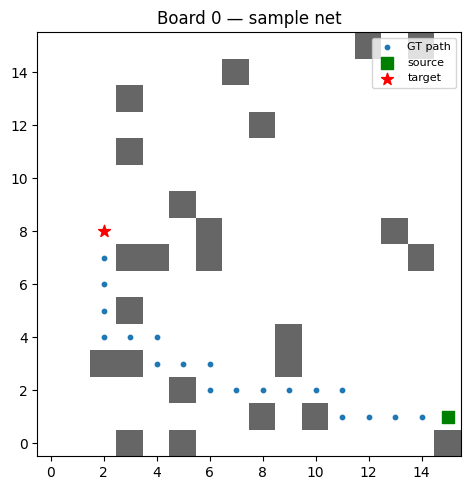

Positive (on-path) node rate: 0.0289  -> using a class-weighted loss


In [ ]:
def visualize_board_instance(data, title="Sample board instance"):
    """Quick visual sanity check: obstacles, source/target pins, and the BFS ground-truth path."""
    meta = meta_of(data)
    size, grid = meta['size'], meta['grid']
    path_mask = data.y.numpy().reshape(size, size)  # valid: node order matches this reshape

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.imshow(grid.T, cmap='Greys', origin='lower', alpha=0.6)
    ys, xs = np.where(path_mask.T == 1)
    ax.scatter(xs, ys, s=10, c='tab:blue', label='GT path')
    sx, sy = meta['source']
    tx, ty = meta['target']
    ax.scatter([sx], [sy], c='green', s=80, marker='s', label='source')
    ax.scatter([tx], [ty], c='red', s=80, marker='*', label='target')
    ax.set_title(title)
    ax.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()


visualize_board_instance(all_graphs[0], title=f"Board {meta_of(all_graphs[0])['board_id']} — sample net")

# Class balance check: the routing-decision label is heavily imbalanced.
pos = sum(int(g.y.sum()) for g in all_graphs)
tot = sum(int(g.y.numel()) for g in all_graphs)
print(f"Positive (on-path) node rate: {pos / tot:.4f}  -> using a class-weighted loss")
POS_WEIGHT = (tot - pos) / max(pos, 1)


## Phase 6: Train, Validation and Test Split

Boards are split 70/15/15 into train, validation and test sets, by board and not by graph.

Splitting by graph could put two nets from the same board into different sets. The model could then memorise that board's obstacle layout and overstate its performance.

### Cell 9: Split the boards

Splits the boards and creates the three data loaders.

In [ ]:
board_ids = list({meta_of(g)['board_id'] for g in all_graphs})
random.Random(SEED).shuffle(board_ids)

n = len(board_ids)
n_train = int(0.70 * n)
n_val = int(0.15 * n)
train_ids = set(board_ids[:n_train])
val_ids = set(board_ids[n_train:n_train + n_val])
test_ids = set(board_ids[n_train + n_val:])

train_graphs = [g for g in all_graphs if meta_of(g)['board_id'] in train_ids]
val_graphs   = [g for g in all_graphs if meta_of(g)['board_id'] in val_ids]
test_graphs  = [g for g in all_graphs if meta_of(g)['board_id'] in test_ids]

print(f"Boards -> train: {len(train_ids)} ({len(train_ids)/n:.0%}), "
      f"val: {len(val_ids)} ({len(val_ids)/n:.0%}), "
      f"test: {len(test_ids)} ({len(test_ids)/n:.0%})")
print(f"Graphs -> train: {len(train_graphs)}, val: {len(val_graphs)}, test: {len(test_graphs)}")

train_loader = DataLoader(train_graphs, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_graphs, batch_size=8, shuffle=False)
test_loader  = DataLoader(test_graphs, batch_size=8, shuffle=False)


Boards -> train: 28 (70%), val: 6 (15%), test: 6 (15%)
Graphs -> train: 168, val: 28, test: 30


## Phase 7: GCN Model

The first model is a stacked Graph Convolutional Network. Standard GCN layers cannot use edge features, so this model relies on node features only.

That gap is what the GAT in the next phase addresses, which keeps the comparison between the two fair.

### Cell 10: GCN router

Three convolution layers followed by a per-node MLP head that outputs one logit per cell.

In [ ]:
class GCNRouter(nn.Module):
    """
    GCN baseline: stacked graph-convolution layers followed by a per-node MLP
    head. Outputs one raw logit per node (on the route or not).
    """
    def __init__(self, in_dim=7, hidden_dim=64, n_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList([GCNConv(in_dim, hidden_dim)])
        for _ in range(n_layers - 1):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, edge_index):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.head(x).squeeze(-1)


## Phase 8: GAT Model

The second model is a Graph Attention Network, kept as close to the GCN as practical. The one deliberate difference is that it also reads the 5 edge features through `edge_dim`.

Each cell can then weight its neighbours using both learned attention and explicit edge information.

### Cell 11: GAT router

Graph attention layers with edge features, followed by the same MLP head as the GCN.

In [ ]:
class GATRouter(nn.Module):
    """
    GAT model: attention layers give each neighbour a learned weight, and edge
    features are passed in through `edge_dim`, which the GCN baseline does not use.
    """
    def __init__(self, in_dim=7, edge_dim=5, hidden_dim=64, heads=4, n_layers=3, dropout=0.2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_dim, hidden_dim, heads=heads, edge_dim=edge_dim, dropout=dropout))
        for _ in range(n_layers - 2):
            self.convs.append(
                GATConv(hidden_dim * heads, hidden_dim, heads=heads, edge_dim=edge_dim, dropout=dropout)
            )
        # Final layer: heads=1 so the output stays at hidden_dim (not hidden_dim * heads).
        self.convs.append(
            GATConv(hidden_dim * heads, hidden_dim, heads=1, edge_dim=edge_dim, dropout=dropout)
        )
        self.dropout = dropout
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, edge_index, edge_attr):
        for conv in self.convs:
            x = F.elu(conv(x, edge_index, edge_attr))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.head(x).squeeze(-1)


## Phase 9: Training and Validation Loop

One shared training function trains both models, so the comparison stays controlled.

Validation F1 is used to judge each model and to trigger early stopping. The weights are saved to `checkpoints/` every time validation F1 improves, which is where `gcn_best.pt` and `gat_best.pt` come from.

### Cell 12: Training functions

Defines one function for a single epoch and one for the full training loop with early stopping.

In [ ]:
def run_epoch(model, loader, optimizer=None, uses_edge_attr=False):
    """One pass over `loader`. Trains if `optimizer` is given, otherwise evaluates only."""
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()
    total_loss, all_logits, all_labels = 0.0, [], []

    for batch in loader:
        batch = batch.to(DEVICE)
        with torch.set_grad_enabled(train_mode):
            if uses_edge_attr:
                logits = model(batch.x, batch.edge_index, batch.edge_attr)
            else:
                logits = model(batch.x, batch.edge_index)
            loss = F.binary_cross_entropy_with_logits(
                logits, batch.y.float(),
                pos_weight=torch.tensor(POS_WEIGHT, device=DEVICE),  # counteract class imbalance
            )
            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * batch.num_graphs
        all_logits.append(logits.detach().cpu())
        all_labels.append(batch.y.detach().cpu())

    all_logits = torch.cat(all_logits)
    all_labels = torch.cat(all_labels)
    preds = (torch.sigmoid(all_logits) > 0.5).long()
    _, _, f1, _ = precision_recall_fscore_support(all_labels, preds, average='binary', zero_division=0)
    return total_loss / len(loader.dataset), f1


def train_model(model, name, uses_edge_attr, n_epochs=40, lr=1e-3, patience=8):
    """
    Train with early stopping on validation F1. The best weights are saved to
    checkpoints/{name}_best.pt and reloaded before returning.
    """
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    best_val_f1, epochs_no_improve = -1.0, 0
    history = {'train_loss': [], 'val_loss': [], 'val_f1': []}
    ckpt_path = f"checkpoints/{name}_best.pt"

    for epoch in range(1, n_epochs + 1):
        train_loss, _ = run_epoch(model, train_loader, optimizer, uses_edge_attr)
        val_loss, val_f1 = run_epoch(model, val_loader, None, uses_edge_attr)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        print(f"[{name}] epoch {epoch:02d} | train_loss {train_loss:.4f} | "
              f"val_loss {val_loss:.4f} | val_F1 {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1, epochs_no_improve = val_f1, 0
            torch.save(model.state_dict(), ckpt_path)  # save weights whenever validation improves
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"[{name}] early stopping at epoch {epoch} (best val F1 {best_val_f1:.4f})")
                break

    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))  # reload best weights
    return model, history


## Phase 10: Train the GCN

Trains the GCN for up to 40 epochs with early stopping.

### Cell 13: Train the GCN

Trains the model and reloads the best checkpoint.

In [ ]:
gcn_model = GCNRouter(in_dim=7, hidden_dim=64, n_layers=3, dropout=0.2)
gcn_model, gcn_history = train_model(gcn_model, name="gcn", uses_edge_attr=False, n_epochs=40)


[gcn] epoch 01 | train_loss 1.3274 | val_loss 1.4426 | val_F1 0.0000
[gcn] epoch 02 | train_loss 1.3270 | val_loss 1.4327 | val_F1 0.0603
[gcn] epoch 03 | train_loss 1.3044 | val_loss 1.4233 | val_F1 0.0768
[gcn] epoch 04 | train_loss 1.2914 | val_loss 1.4086 | val_F1 0.0776
[gcn] epoch 05 | train_loss 1.2554 | val_loss 1.3698 | val_F1 0.0809
[gcn] epoch 06 | train_loss 1.2155 | val_loss 1.3269 | val_F1 0.0903
[gcn] epoch 07 | train_loss 1.1750 | val_loss 1.3190 | val_F1 0.0811
[gcn] epoch 08 | train_loss 1.1576 | val_loss 1.2525 | val_F1 0.0995
[gcn] epoch 09 | train_loss 1.1281 | val_loss 1.2553 | val_F1 0.0961
[gcn] epoch 10 | train_loss 1.1055 | val_loss 1.1826 | val_F1 0.1175
[gcn] epoch 11 | train_loss 1.0918 | val_loss 1.1951 | val_F1 0.1147
[gcn] epoch 12 | train_loss 1.0637 | val_loss 1.1672 | val_F1 0.1287
[gcn] epoch 13 | train_loss 1.0489 | val_loss 1.1585 | val_F1 0.1223
[gcn] epoch 14 | train_loss 1.0501 | val_loss 1.1430 | val_F1 0.1171
[gcn] epoch 15 | train_loss 1.0349

## Phase 11: Train the GAT

Trains the GAT the same way as the GCN, then plots the validation curves of both models side by side.

### Cell 14: Train the GAT

Trains the model and reloads the best checkpoint.

In [ ]:
gat_model = GATRouter(in_dim=7, edge_dim=5, hidden_dim=64, heads=4, n_layers=3, dropout=0.2)
gat_model, gat_history = train_model(gat_model, name="gat", uses_edge_attr=True, n_epochs=40)


[gat] epoch 01 | train_loss 1.3219 | val_loss 1.4301 | val_F1 0.0750
[gat] epoch 02 | train_loss 1.3017 | val_loss 1.3918 | val_F1 0.0745
[gat] epoch 03 | train_loss 1.2631 | val_loss 1.3241 | val_F1 0.0774
[gat] epoch 04 | train_loss 1.1770 | val_loss 1.1382 | val_F1 0.1619
[gat] epoch 05 | train_loss 1.1062 | val_loss 1.1175 | val_F1 0.1191
[gat] epoch 06 | train_loss 1.0981 | val_loss 1.1761 | val_F1 0.0928
[gat] epoch 07 | train_loss 1.0930 | val_loss 1.1337 | val_F1 0.1048
[gat] epoch 08 | train_loss 1.0794 | val_loss 1.0939 | val_F1 0.1272
[gat] epoch 09 | train_loss 1.0620 | val_loss 1.0916 | val_F1 0.1190
[gat] epoch 10 | train_loss 1.0726 | val_loss 1.1110 | val_F1 0.1082
[gat] epoch 11 | train_loss 1.0532 | val_loss 1.0735 | val_F1 0.1363
[gat] epoch 12 | train_loss 1.0456 | val_loss 1.0865 | val_F1 0.1206
[gat] early stopping at epoch 12 (best val F1 0.1619)


### Cell 15: Compare the training curves

Plots validation loss and validation F1 for both models.

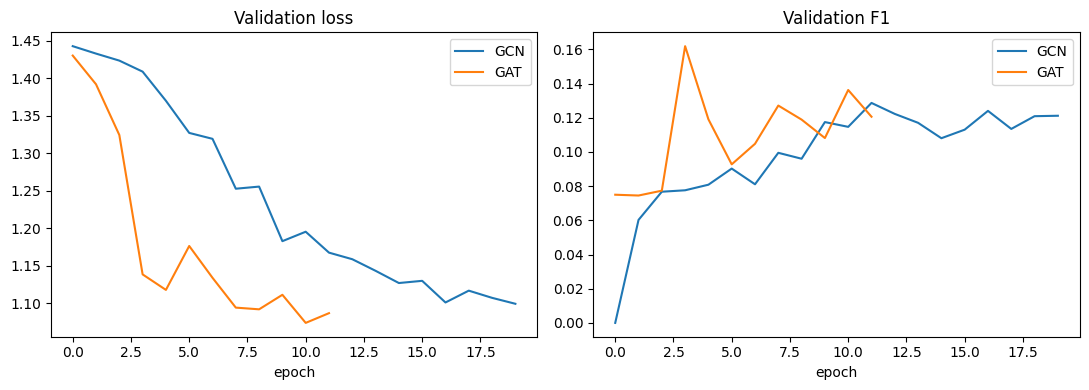

In [ ]:
# Validation curves for GCN and GAT side by side.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(gcn_history['val_loss'], label='GCN')
axes[0].plot(gat_history['val_loss'], label='GAT')
axes[0].set_title('Validation loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(gcn_history['val_f1'], label='GCN')
axes[1].plot(gat_history['val_f1'], label='GAT')
axes[1].set_title('Validation F1'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


## Phase 12: Test Set Evaluation

The test boards (15% of all boards, never used for training or validation) are used once, here, for the final numbers: accuracy, precision, recall, F1 and a confusion matrix for each model.

### Cell 16: Evaluate both models

Reports the test metrics and shows a confusion matrix for the GCN and the GAT.


=== GCN — held-out TEST set ===
Accuracy : 0.7236
Precision: 0.0785
Recall   : 0.6426
F1-score : 0.1398


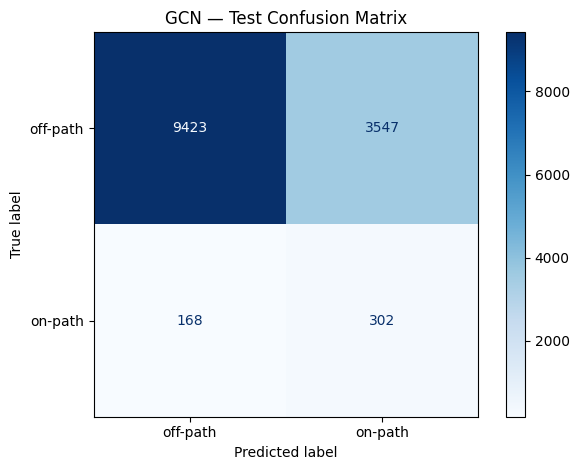


=== GAT — held-out TEST set ===
Accuracy : 0.7922
Precision: 0.0820
Recall   : 0.4851
F1-score : 0.1404


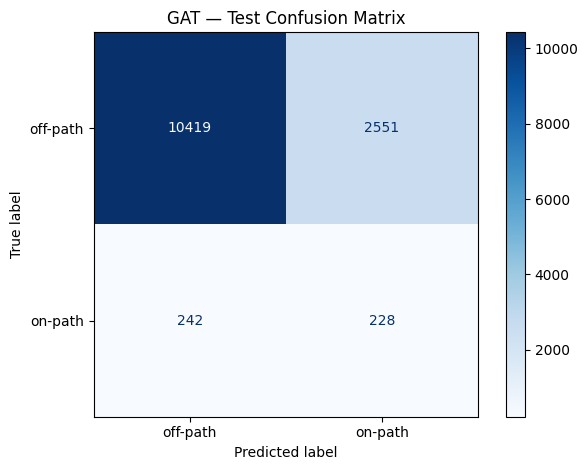

In [ ]:
def evaluate_on_test(model, name, uses_edge_attr):
    """Runs the trained model once over the held-out test set and reports final metrics."""
    model.eval()
    all_logits, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(DEVICE)
            logits = model(batch.x, batch.edge_index, batch.edge_attr) if uses_edge_attr \
                else model(batch.x, batch.edge_index)
            all_logits.append(logits.cpu())
            all_labels.append(batch.y.cpu())

    logits = torch.cat(all_logits)
    labels = torch.cat(all_labels).numpy()
    preds = (torch.sigmoid(logits) > 0.5).long().numpy()

    acc = accuracy_score(labels, preds)
    prec, rec, f1, _ = precision_recall_fscore_support(labels, preds, average='binary', zero_division=0)
    cm = confusion_matrix(labels, preds)

    print(f"\n=== {name} — held-out TEST set ===")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['off-path', 'on-path'])
    disp.plot(cmap='Blues', values_format='d')
    plt.title(f"{name} — Test Confusion Matrix")
    plt.tight_layout(); plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1, 'confusion_matrix': cm.tolist()}


gcn_test_metrics = evaluate_on_test(gcn_model, "GCN", uses_edge_attr=False)
gat_test_metrics = evaluate_on_test(gat_model, "GAT", uses_edge_attr=True)


## Phase 13: A* Routing Integration

This is the hybrid design. The GNN gives each cell a probability of being on the route, and A* searches for the actual path. That probability becomes a small, bounded discount on the cost of stepping into the cell.

Obstacles stay blocked no matter what the model predicts. A poor prediction can only make the search less efficient, and it can never produce an invalid route.

### Cell 17: A* router

Defines the A* search and a helper that turns a trained model's output into a grid of probabilities.

In [ ]:
def astar_route(grid, source, target, node_probs=None, alpha=5.0):
    """
    A* search on the routing grid, optionally guided by `node_probs` (a
    [size, size] array of GNN on-route probabilities). Guidance only discounts
    the step cost, and obstacles stay blocked.
    Returns (path, expansions); path is None if the net cannot be routed.
    """
    size = grid.shape[0]
    sx, sy = source
    tx, ty = target

    def heuristic(x, y):
        return abs(x - tx) + abs(y - ty)  # admissible Manhattan-distance heuristic

    def step_cost(x, y):
        base = 1.0
        if node_probs is None:
            return base
        return base * (1.0 - alpha * 0.01 * node_probs[x, y])  # small, bounded discount

    open_set = [(heuristic(sx, sy), 0.0, (sx, sy))]
    came_from = {}
    g_score = {(sx, sy): 0.0}
    visited = set()
    expansions = 0

    while open_set:
        _, g, (x, y) = heapq.heappop(open_set)
        if (x, y) in visited:
            continue
        visited.add((x, y))
        expansions += 1
        if (x, y) == (tx, ty):
            path = [(x, y)]
            while (x, y) in came_from:
                x, y = came_from[(x, y)]
                path.append((x, y))
            path.reverse()
            return path, expansions
        for dx, dy in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
            nx_, ny_ = x + dx, y + dy
            if 0 <= nx_ < size and 0 <= ny_ < size and grid[nx_, ny_] == 0:
                tentative_g = g + step_cost(nx_, ny_)
                if tentative_g < g_score.get((nx_, ny_), float('inf')):
                    g_score[(nx_, ny_)] = tentative_g
                    came_from[(nx_, ny_)] = (x, y)
                    heapq.heappush(open_set, (tentative_g + heuristic(nx_, ny_), tentative_g, (nx_, ny_)))

    return None, expansions  # unroutable under current obstacles


def predict_node_probs(model, data, uses_edge_attr):
    """Runs the trained GNN on one (un-batched) graph and reshapes predictions to a size x size grid."""
    size = meta_of(data)['size']
    model.eval()
    with torch.no_grad():
        d = data.to(DEVICE)
        logits = model(d.x, d.edge_index, d.edge_attr) if uses_edge_attr else model(d.x, d.edge_index)
        probs = torch.sigmoid(logits).cpu().numpy()
    return probs.reshape(size, size)


## Phase 14: Route Generation and Visualization

Routes one test net three ways (plain A*, GCN-guided A* and GAT-guided A*) and plots each result.

At this stage the output is a grid representation of the routed net, not a `.kicad_pcb` file.

### Cell 18: Route and plot one net

Compares the three routes on the first test net, showing path length and A* expansions.

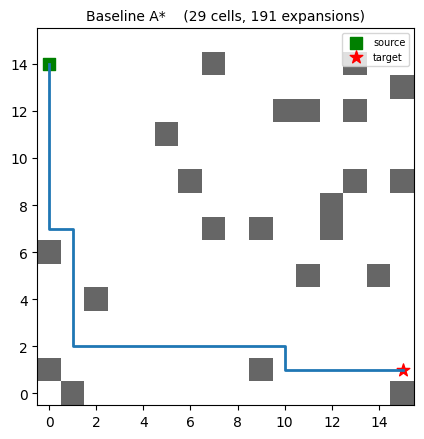

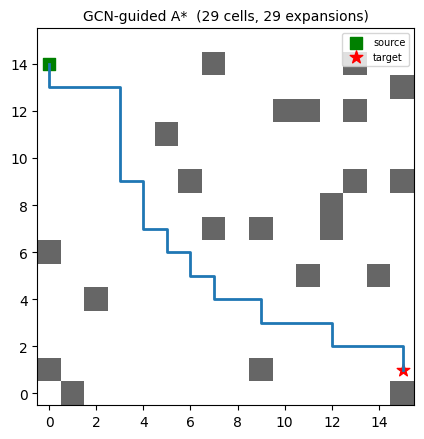

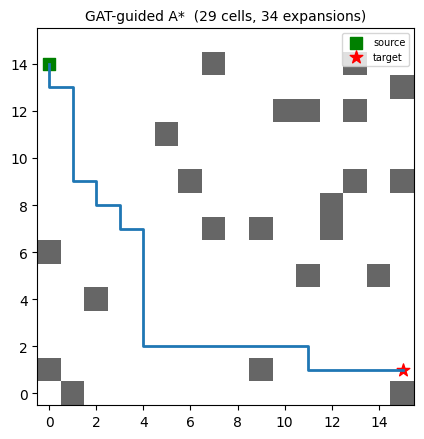

In [ ]:
def visualize_route(grid, path, title):
    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.imshow(grid.T, cmap='Greys', origin='lower', alpha=0.6)
    if path:
        xs, ys = zip(*path)
        ax.plot(xs, ys, c='tab:blue', linewidth=2)
        ax.scatter([xs[0]], [ys[0]], c='green', marker='s', s=70, label='source')
        ax.scatter([xs[-1]], [ys[-1]], c='red', marker='*', s=90, label='target')
    ax.set_title(title, fontsize=10)
    ax.legend(loc='upper right', fontsize=7)
    plt.tight_layout(); plt.show()


sample = test_graphs[0]
meta = meta_of(sample)
grid, source, target = meta['grid'], meta['source'], meta['target']

gcn_probs = predict_node_probs(gcn_model, sample, uses_edge_attr=False)
gat_probs = predict_node_probs(gat_model, sample, uses_edge_attr=True)

t0 = time.time(); base_path, base_exp = astar_route(grid, source, target); t_base = time.time() - t0
t0 = time.time(); gcn_path, gcn_exp = astar_route(grid, source, target, node_probs=gcn_probs); t_gcn = time.time() - t0
t0 = time.time(); gat_path, gat_exp = astar_route(grid, source, target, node_probs=gat_probs); t_gat = time.time() - t0

visualize_route(grid, base_path, f"Baseline A*    ({len(base_path)} cells, {base_exp} expansions)")
visualize_route(grid, gcn_path,  f"GCN-guided A*  ({len(gcn_path)} cells, {gcn_exp} expansions)")
visualize_route(grid, gat_path,  f"GAT-guided A*  ({len(gat_path)} cells, {gat_exp} expansions)")


## Phase 15: Aggregate Routing Metrics

Computes the routing metrics over the whole test set for plain A*, GCN-guided A* and GAT-guided A*: routing completion, wire length, vias, DRC violations and routing time.

Vias are always 0 here because the task uses a single copper layer. Phase 18 explains where multi-layer via counting would go.

### Cell 19: Route every test net

Runs all three routers over the test set, prints a summary for each and plots the headline metrics.


=== Baseline A* — 30 held-out test nets ===
Routing completion : 100.00%
Avg wire length    : 15.67
Avg A* expansions  : 56.6
Avg routing time   : 0.20 ms
DRC violations     : 0

=== GCN-guided A* — 30 held-out test nets ===
Routing completion : 100.00%
Avg wire length    : 15.67
Avg A* expansions  : 21.2
Avg routing time   : 0.19 ms
DRC violations     : 0

=== GAT-guided A* — 30 held-out test nets ===
Routing completion : 100.00%
Avg wire length    : 15.67
Avg A* expansions  : 22.0
Avg routing time   : 0.19 ms
DRC violations     : 0


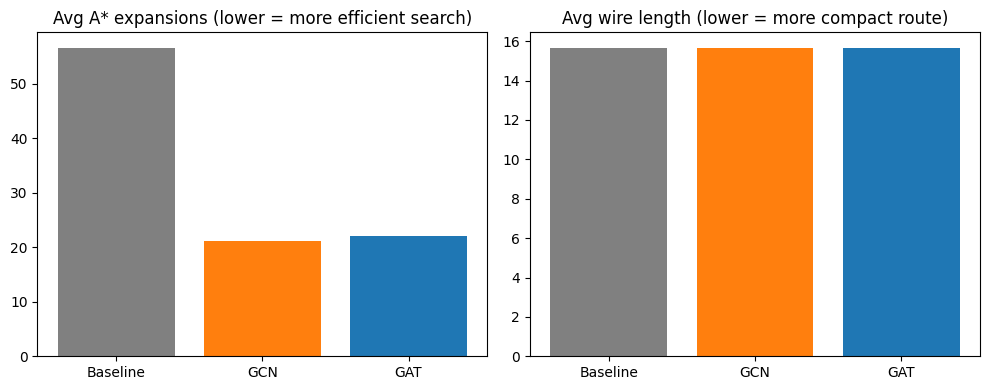

In [ ]:
def route_all(graphs, node_probs_fn=None):
    """Runs A* over every graph in `graphs`, optionally guided by a model's predictions."""
    results = []
    for g in graphs:
        meta = meta_of(g)
        probs = node_probs_fn(g) if node_probs_fn else None
        t0 = time.time()
        path, expansions = astar_route(meta['grid'], meta['source'], meta['target'], node_probs=probs)
        elapsed = time.time() - t0
        drc_violations = sum(1 for (x, y) in path if meta['grid'][x, y] == 1) if path else 0
        results.append({
            'board_id': meta['board_id'],
            'routed': path is not None,
            'wire_length': len(path) if path else None,
            'vias': 0,  # single-layer synthetic task; multi-layer boards would count layer changes here
            'drc_violations': drc_violations,  # should always be 0 -- A* never steps on an obstacle
            'expansions': expansions,
            'time_s': elapsed,
        })
    return results


baseline_results = route_all(test_graphs)
gcn_results = route_all(test_graphs, lambda g: predict_node_probs(gcn_model, g, uses_edge_attr=False))
gat_results = route_all(test_graphs, lambda g: predict_node_probs(gat_model, g, uses_edge_attr=True))


def summarize(results, name):
    routed = [r for r in results if r['routed']]
    print(f"\n=== {name} — {len(results)} held-out test nets ===")
    print(f"Routing completion : {len(routed) / len(results):.2%}")
    print(f"Avg wire length    : {np.mean([r['wire_length'] for r in routed]):.2f}")
    print(f"Avg A* expansions  : {np.mean([r['expansions'] for r in results]):.1f}")
    print(f"Avg routing time   : {np.mean([r['time_s'] for r in results]) * 1000:.2f} ms")
    print(f"DRC violations     : {sum(r['drc_violations'] for r in results)}")


summarize(baseline_results, "Baseline A*")
summarize(gcn_results, "GCN-guided A*")
summarize(gat_results, "GAT-guided A*")

# Compare the headline metrics.
labels = ['Baseline', 'GCN', 'GAT']
exp_means = [np.mean([r['expansions'] for r in rs]) for rs in (baseline_results, gcn_results, gat_results)]
len_means = [np.mean([r['wire_length'] for r in rs if r['routed']])
             for rs in (baseline_results, gcn_results, gat_results)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, exp_means, color=['gray', 'tab:orange', 'tab:blue'])
axes[0].set_title('Avg A* expansions (lower = more efficient search)')
axes[1].bar(labels, len_means, color=['gray', 'tab:orange', 'tab:blue'])
axes[1].set_title('Avg wire length (lower = more compact route)')
plt.tight_layout(); plt.show()


## Phase 16: Unseen Board Check

The board-level split already keeps the test set away from training. This is a stricter check: six new synthetic boards generated with fresh seeds that were never part of the original 40-board pool.

### Cell 20: Evaluate on new boards

Builds the new boards and compares the three routers on them.

In [ ]:
holdout_boards = [
    generate_synthetic_board(board_id=1000 + i, seed=1000 + i, size=24, n_nets=6, obstacle_density=0.20)
    for i in range(6)
]
holdout_boards = [preprocess_board(b) for b in holdout_boards]
holdout_graphs = [board_net_to_graph(b, net) for b in holdout_boards for net in b['nets']]

print(f"Truly unseen holdout set: {len(holdout_graphs)} nets across {len(holdout_boards)} new boards")

holdout_base = route_all(holdout_graphs)
holdout_gcn = route_all(holdout_graphs, lambda g: predict_node_probs(gcn_model, g, uses_edge_attr=False))
holdout_gat = route_all(holdout_graphs, lambda g: predict_node_probs(gat_model, g, uses_edge_attr=True))

summarize(holdout_base, "Baseline A* (fresh unseen boards)")
summarize(holdout_gcn, "GCN-guided A* (fresh unseen boards)")
summarize(holdout_gat, "GAT-guided A* (fresh unseen boards)")


Truly unseen holdout set: 36 nets across 6 new boards

=== Baseline A* (fresh unseen boards) — 36 held-out test nets ===
Routing completion : 100.00%
Avg wire length    : 17.58
Avg A* expansions  : 62.0
Avg routing time   : 0.23 ms
DRC violations     : 0

=== GCN-guided A* (fresh unseen boards) — 36 held-out test nets ===
Routing completion : 100.00%
Avg wire length    : 17.58
Avg A* expansions  : 29.6
Avg routing time   : 0.23 ms
DRC violations     : 0

=== GAT-guided A* (fresh unseen boards) — 36 held-out test nets ===
Routing completion : 100.00%
Avg wire length    : 17.58
Avg A* expansions  : 28.9
Avg routing time   : 0.22 ms
DRC violations     : 0


## Phase 17: Save Artifacts

The best weights are already saved during training. Here we copy them under `_final_tested` names to mark the exact models behind the reported numbers.

We also write a JSON manifest with the configuration and results, so the run can be reproduced.

### Cell 21: Save the final weights and manifest

Copies the checkpoints and writes `results/run_manifest.json`.

In [ ]:
import shutil

# Freeze the exact weights the reported test/routing numbers came from.
shutil.copy('checkpoints/gcn_best.pt', 'checkpoints/gcn_final_tested.pt')
shutil.copy('checkpoints/gat_best.pt', 'checkpoints/gat_final_tested.pt')

manifest = {
    'seed': SEED,
    'n_boards_total': len(boards),
    'split': {'train': len(train_ids), 'val': len(val_ids), 'test': len(test_ids)},
    'gcn_test_metrics': gcn_test_metrics,
    'gat_test_metrics': gat_test_metrics,
    'gcn_checkpoint': 'checkpoints/gcn_final_tested.pt',
    'gat_checkpoint': 'checkpoints/gat_final_tested.pt',
}
with open('results/run_manifest.json', 'w') as f:
    json.dump(manifest, f, indent=2)

print("Saved:")
print(" - checkpoints/gcn_best.pt          (best-validation weights)")
print(" - checkpoints/gat_best.pt          (best-validation weights)")
print(" - checkpoints/gcn_final_tested.pt  (frozen copy used for the reported test/routing results)")
print(" - checkpoints/gat_final_tested.pt  (frozen copy used for the reported test/routing results)")
print(" - results/run_manifest.json        (config + metrics, for reproducibility)")


Saved:
 - checkpoints/gcn_best.pt          (best-validation weights)
 - checkpoints/gat_best.pt          (best-validation weights)
 - checkpoints/gcn_final_tested.pt  (frozen copy used for the reported test/routing results)
 - checkpoints/gat_final_tested.pt  (frozen copy used for the reported test/routing results)
 - results/run_manifest.json        (config + metrics, for reproducibility)


## Phase 18: Conclusion and Next Steps

**What this notebook shows.** The pipeline runs end to end: dataset, graph, GCN and GAT, A*, metrics and an unseen-board check. It reports routing completion, wire length, DRC violations, routing time, accuracy, precision, recall, F1 and a confusion matrix, along with a direct GCN versus GAT comparison, all on boards the models never trained on.

**Why KiCad is a small step from here.** Nodes and edges already carry the fields a real board needs, so moving to KiCad changes the data layer only. The graph construction, the models and the A* router stay as they are.

**Next steps, in order:**

1. **Inspect the real datasets.** Set `DOWNLOAD_REAL_DATA = True` in Cell 4, clone PCBench and PCBWorld, and open a few files by hand. Check whether they hold `.kicad_pcb` or netlist files, a ready-made graph format, or something else.
2. **Implement `load_real_board()`.** Return the same schema as `generate_synthetic_board()`. For `.kicad_pcb` files, KiCad's `pcbnew` Python API (or `kiutils` / `pcb-tools`) can read pad positions for terminals and keep-outs for obstacles.
3. **Use real ground truth where it exists.** If a board already has routed tracks, use them as labels in place of the BFS paths from Phase 3, and keep BFS as a fallback for incomplete boards.
4. **Add multi-layer support.** The `layer` node feature and `layer_transition` edge feature are already reserved. Add via nodes and edges between layers in `board_net_to_graph`, and let `astar_route` change layers at a via cost.
5. **Use KiCad's real DRC.** The counter in Phase 15 only checks whether a path touches an obstacle cell. After exporting, run KiCad's own DRC to check clearance, trace width and via rules.
6. **Export routes to `.kicad_pcb`.** Turn each A* path into `PCB_TRACK` segments at the board's trace width, and add `PCB_VIA` objects at layer changes, using `pcbnew`.
7. **Test on two or three real boards by hand first.** Check the parsing and a few exported routes in KiCad before running on the full PCBench and PCBWorld sets.

Only the loading step in Phase 2 and a new export step after Phase 14 need new code. Everything else can stay as it is.